# Обучение модели ResNet18 для классификации AI vs Human Generated Images

Этот notebook содержит код для обучения модели ResNet18 на датасете Train_1 и оценки качества на Test_1.

## 1. Импорт библиотек

In [1]:
!pip install -q tensorboard boto3 dvc dvc-s3
print('Done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.1/470.1 kB 9.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.2/451.2 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.2/214.2 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.7/375.7 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.1/87.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.utils.tensorboard import SummaryWriter
from PIL import Image
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import boto3
from botocore.client import Config
import json
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

2026-05-22 19:12:43.272199: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779477163.295447     326 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779477163.303253     326 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779477163.323705     326 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779477163.323725     326 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779477163.323727     326 computation_placer.cc:177] computation placer alr

Using device: cuda


In [ ]:
base = '/kaggle/input/datasets/dataset/ai-vs-human-generated-dataset-hw/'

train1_csv = f'{base}/Train_1/train.csv'
train1_root = f'{base}/Train_1'
test1_csv = f'{base}/Test_1/test.csv'
test1_root = f'{base}/Test_1'

train2_csv = f'{base}/Train_2/train.csv'
train2_root = f'{base}/Train_2'
test2_csv = f'{base}/Test_2/test.csv'
test2_root = f'{base}/Test_2'

work_dir = '/kaggle/working'
model_v1 = f'{work_dir}/model_v1.pth'
model_v2 = f'{work_dir}/model_v2.pth'
log_dir_v1 = f'{work_dir}/logs/v1'
log_dir_v2 = f'{work_dir}/logs/v2'

config_train = {
    'batch_size': 64,
    'num_epochs': 10,
    'lr': 1e-3,
    'scheduler_step': 5,
    'scheduler_gamma': 0.1,
    'num_workers': 2,
    'num_classes': 2,
    'image_size': 224,
    'model': 'resnet18_v1',
}

config_finetune = {
    'batch_size': 64,
    'num_epochs': 5,
    'lr': 1e-4,
    'scheduler_step': 3,
    'scheduler_gamma': 0.1,
    'num_workers': 2,
    'num_classes': 2,
    'image_size': 224,
    'model': 'resnet18_v2_finetuned',
}

s3_endpoint = 'http://localhost:9000'
s3_access_key = 'minioadmin'
s3_secret_key = 'minioadmin'
s3_bucket = 'models'

## 2. Подготовка данных

In [4]:
class ImageDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.root_dir = Path(root_dir)
        self.transform = transform
    
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        file_name = self.data.iloc[idx]['file_name']
        img_path = self.root_dir / file_name
        if not img_path.exists():
            file_name = file_name.replace('train_data/', 'test_data/')
            img_path = self.root_dir / file_name
        image = Image.open(img_path).convert('RGB')
        label = int(self.data.iloc[idx]['label'])
        if self.transform:
            image = self.transform(image)
        return image, label

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageDataset(
    csv_file=train1_csv,
    root_dir=train1_root,
    transform=train_transform,
)
test_dataset = ImageDataset(
    csv_file=test1_csv,
    root_dir=test1_root,
    transform=test_transform,
)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

print(f'Train dataset size: {len(train_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')

Train dataset size: 9993
Test dataset size: 3997


## 3. Создание модели ResNet18

In [6]:
model = models.resnet18(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

print(f'Model architecture:')
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s] 


Model architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): R

## 4. Определение функции потерь и оптимизатора

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

## 5. Функция обучения

In [8]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in tqdm(dataloader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    # добавьте подсчет epoch_loss, epoch_acc, epoch_f1
    n = len(dataloader.dataset)
    epoch_loss = running_loss / n
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='binary')
    return epoch_loss, epoch_acc, epoch_f1

## 6. Функция валидации

In [9]:
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # добавьте подсчет epoch_loss, epoch_acc, epoch_f1, epoch_precision, epoch_recall
    n = len(dataloader.dataset)
    epoch_loss = running_loss / n
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='binary')
    epoch_precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    epoch_recall  = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    
    return epoch_loss, epoch_acc, epoch_f1, epoch_precision, epoch_recall

## 7. Обучение модели

In [10]:
writer = SummaryWriter(log_dir=log_dir_v1)

# Добавьте логгирование метрик для tensorboard
writer.add_hparams(
    hparam_dict={
        'lr': config_train['lr'],
        'batch_size': config_train['batch_size'],
        'num_epochs': config_train['num_epochs'],
        'scheduler_step': config_train['scheduler_step'],
        'scheduler_gamma': config_train['scheduler_gamma'],
    },
    metric_dict={'placeholder': 0},
)

num_epochs = config_train['num_epochs']
train_losses = []
train_accs = []
train_f1s = []

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 50)

    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
    scheduler.step()

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)

    writer.add_scalar('Train/Loss', train_loss, epoch)
    writer.add_scalar('Train/Accuracy', train_acc, epoch)
    writer.add_scalar('Train/F1', train_f1, epoch)
    writer.add_scalar('LR', scheduler.get_last_lr()[0], epoch)

    print(f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}')

print('\nTraining completed!')


Epoch 1/10
--------------------------------------------------


Training: 100%|██████████| 313/313 [00:54<00:00,  5.73it/s]


Train Loss: 0.3815, Acc: 0.8375, F1: 0.8355

Epoch 2/10
--------------------------------------------------


Training: 100%|██████████| 313/313 [00:45<00:00,  6.88it/s]


Train Loss: 0.2859, Acc: 0.8812, F1: 0.8814

Epoch 3/10
--------------------------------------------------


...

Train Loss: 0.1038, Acc: 0.9589, F1: 0.9589

Epoch 9/10
--------------------------------------------------


Training: 100%|██████████| 313/313 [00:45<00:00,  6.95it/s]


Train Loss: 0.0900, Acc: 0.9664, F1: 0.9664

Epoch 10/10
--------------------------------------------------


Training: 100%|██████████| 313/313 [00:45<00:00,  6.81it/s]

Train Loss: 0.0876, Acc: 0.9692, F1: 0.9692

Training completed!


## 8. Оценка модели на тестовом датасете

In [11]:
base = '/kaggle/input/datasets/stanislavkim/dataset/ai-vs-human-generated-dataset-hw'

In [12]:
# Добавьте логику оценки модели на тестовом датасете, как метрику в tensorboard
# pip install tensorboard
# команда для поднятия
# tensorboard --logdir=my_logs

test_loss, test_acc, test_f1, test_prec, test_rec = validate(model, test_loader, criterion, device)

writer.add_scalar('Test/Loss', test_loss, 0)
writer.add_scalar('Test/Accuracy', test_acc, 0)
writer.add_scalar('Test/F1', test_f1, 0)
writer.add_scalar('Test/Precision', test_prec, 0)
writer.add_scalar('Test/Recall', test_rec, 0)

writer.close()

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test F1: {test_f1:.4f}')
print(f'Test Precision: {test_prec:.4f}')
print(f'Test Recall: {test_rec:.4f}')

torch.save(model.state_dict(), model_v1)
print(f'\nModel v1 saved -> {model_v1}')

Validation: 100%|██████████| 125/125 [00:17<00:00,  7.33it/s]

Test Loss: 0.0899
Test Accuracy: 0.9670
Test F1: 0.9667
Test Precision: 0.9751
Test Recall: 0.9585

Model v1 saved -> /kaggle/working/model_v1.pth


## 9. Дообучите модель на втором датасете и постройте DVC пайплайн

In [13]:
# Добавьте логику дообучения
# Добавьте PVC пайплайн

In [22]:
# подготовка данных
train_transform2, test_transform2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
]), transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset2 = ImageDataset(csv_file=train2_csv, root_dir=train2_root, transform=train_transform2)
test_dataset2  = ImageDataset(csv_file=test2_csv,  root_dir=test2_root,  transform=test_transform2)

train_loader2 = DataLoader(train_dataset2, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
test_loader2  = DataLoader(test_dataset2,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train2: {len(train_dataset2)} | Test2: {len(test_dataset2)}')

# веса v1
model_v2 = models.resnet18(weights=None)
model_v2.fc = nn.Linear(model_v2.fc.in_features, 2)
model_v2.load_state_dict(torch.load(model_v1, map_location=device))
model_v2 = model_v2.to(device)
print('Weights from v1 loaded')

# оптимизатор и scheduler
criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(model_v2.parameters(), lr=config_finetune['lr'])
scheduler2 = optim.lr_scheduler.StepLR(
    optimizer2, step_size=config_finetune['scheduler_step'], gamma=config_finetune['scheduler_gamma']
)

# tensorboard
writer2 = SummaryWriter(log_dir=log_dir_v2)
writer2.add_hparams(
    hparam_dict={
        'lr': config_finetune['lr'],
        'batch_size': config_finetune['batch_size'],
        'num_epochs': config_finetune['num_epochs'],
        'scheduler_step': config_finetune['scheduler_step'],
        'scheduler_gamma': config_finetune['scheduler_gamma'],
    },
    metric_dict={'placeholder': 0},
)

Train2: 3997 | Test2: 2000
Weights from v1 loaded


In [23]:
# дообучение
num_epochs2 = config_finetune['num_epochs']
train_losses2 = []
train_accs2 = []
train_f1s2 = []

for epoch in range(num_epochs2):
    print(f'\nEpoch {epoch+1}/{num_epochs2}')
    print('-' * 50)

    train_loss, train_acc, train_f1 = train_epoch(model_v2, train_loader2, criterion2, optimizer2, device)
    scheduler2.step()

    train_losses2.append(train_loss)
    train_accs2.append(train_acc)
    train_f1s2.append(train_f1)

    writer2.add_scalar('Train/Loss', train_loss, epoch)
    writer2.add_scalar('Train/Accuracy', train_acc, epoch)
    writer2.add_scalar('Train/F1', train_f1, epoch)
    writer2.add_scalar('LR', scheduler2.get_last_lr()[0], epoch)

    print(f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}')


Epoch 1/5
--------------------------------------------------


Training: 100%|██████████| 63/63 [00:25<00:00,  2.47it/s]


Train Loss: 0.1141, Acc: 0.9545, F1: 0.9555

Epoch 2/5
--------------------------------------------------


Training: 100%|██████████| 63/63 [00:23<00:00,  2.71it/s]


Train Loss: 0.1024, Acc: 0.9607, F1: 0.9615

Epoch 3/5
--------------------------------------------------


...

Train Loss: 0.0893, Acc: 0.9672, F1: 0.9679

Epoch 4/5
--------------------------------------------------


Training: 100%|██████████| 63/63 [00:22<00:00,  2.75it/s]


Train Loss: 0.0813, Acc: 0.9697, F1: 0.9703

Epoch 5/5
--------------------------------------------------


Training: 100%|██████████| 63/63 [00:22<00:00,  2.78it/s]

Train Loss: 0.0730, Acc: 0.9710, F1: 0.9716


In [24]:
# оценка на Test_2
test_loss2, test_acc2, test_f1_2, test_prec2, test_rec2 = validate(model_v2, test_loader2, criterion2, device)

writer2.add_scalar('Test/Loss', test_loss2, 0)
writer2.add_scalar('Test/Accuracy', test_acc2, 0)
writer2.add_scalar('Test/F1', test_f1_2, 0)
writer2.add_scalar('Test/Precision', test_prec2, 0)
writer2.add_scalar('Test/Recall', test_rec2, 0)
writer2.close()

print(f'\nTest Loss: {test_loss2:.4f}')
print(f'Test Accuracy: {test_acc2:.4f}')
print(f'Test F1: {test_f1_2:.4f}')
print(f'Test Precision: {test_prec2:.4f}')
print(f'Test Recall: {test_rec2:.4f}')

model_v2_path = f'{work_dir}/model_v2.pth'
torch.save(model_v2.state_dict(), model_v2_path)
print(f'\nModel v2 saved -> {model_v2_path}')

print('\nFinetuning completed!')

Validation: 100%|██████████| 32/32 [00:14<00:00,  2.26it/s]


Test Loss: 0.0688
Test Accuracy: 0.9810
Test F1: 0.9808
Test Precision: 0.9848
Test Recall: 0.9769

Model v2 saved -> /kaggle/working/model_v2.pth

Finetuning completed!


## 10. Напишите вывод о полученных результатах

**ResNet18** с предобученными ImageNet весами обучалась 10 эпох. Первые 5 эпох loss чуть медленнее, потом снизилось lr на 5-й эпохе и loss в итоге упал с 0.2054 до 0.0899, accuracy в итоге вышла 0.9585. (большой lr помогает найти окрестность минимума, а потом мы снижаем его чтобы сойтись).

**Дообученная модель v2** уже с весами v1 и обучалась 5 эпох с lr=1e-4. Начиная с 1 эпохи loss был достаточно низким (0.9545), тут помогла изначально хорошая инициализация. accuracy выросла 0.9769. 

**Итоговые тестовые метрики:**

|           | v1 (Test_1) | v2 (Test_2) |
|-----------|-------------|-------------|
| Loss      | 0.0899      | 0.0688      |
| Accuracy  | 0.9670      | 0.9810      |
| F1        | 0.9667      | 0.9808      |
| Precision | 0.9751      | 0.9848      |
| Recall    | 0.9585      | 0.9769      |

In [26]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [27]:
%tensorboard --logdir=/kaggle/working/logs

<IPython.core.display.Javascript object>

## TensorBoard основные графики 

![Loss](hw4_images/loss.png)
![Accuracy](hw4_images/accuracy.png)
![F1](hw4_images/f1.png)
![LR](hw4_images/lr.png)

## DVC

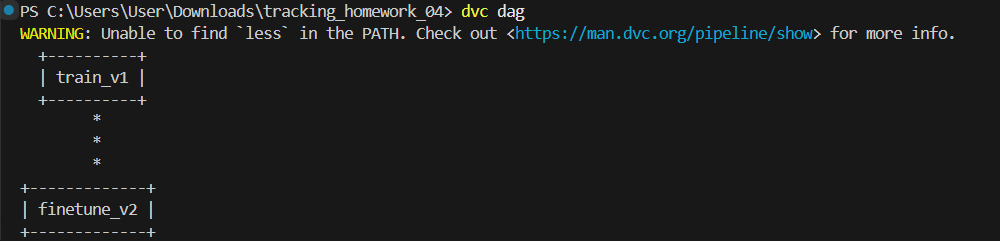